# Question 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

    •	Create a dataset of 500 employees with the following columns:
	•	Employee_ID (1–500)
	•	Department (Random choice: HR, IT, Finance, Sales)
	•	Salary (10k to 50k)
	•	Experience_Years (Random integers between 1–20)
	•	Performance_Score (Random integers 1–5)
	•	Randomly introduce missing values in 10% of Salary and Experience_Years.

In [3]:
np.random.seed(42)
employee_id = np.arange(1,501)
dep = np.random.choice(["HR","IT","Finance","Sales"],size=500)
salary = np.random.randint(10000,50001,size=500)
performance_score = np.random.randint(1,6,size=500)
exp_yrs = np.random.randint(1,21,size=500)
df = pd.DataFrame({"Employee_ID":employee_id,"Department":dep,"Salary":salary,"Experience_Years":exp_yrs,"Performance_Score":performance_score})
# df.set_index("Employee_ID")
df.loc[np.random.choice(df.index,size=50,replace=False),"Salary"] = np.nan
df.loc[np.random.choice(df.index,size=50,replace=False),"Experience_Years"] = np.nan
df

,Employee_ID,Department,Salary,Experience_Years,Performance_Score
0,1,Finance,10190.0,NaN,5
1,2,Sales,20492.0,10.0,4
2,3,HR,45743.0,2.0,1
3,4,Finance,16102.0,13.0,4
4,5,Finance,29778.0,13.0,2
...,...,...,...,...,...
495,496,Finance,11062.0,5.0,1
496,497,Finance,39926.0,15.0,5
497,498,Sales,16229.0,15.0,2
498,499,HR,14632.0,2.0,4


 - Identify missing values
 - Fill missing Salary with the median of that department.
 - Fill missing Experience_Years with the overall mean.

In [4]:
print(df.isna().sum()) # Identified null values
df["Salary"] = df["Salary"].fillna(df.groupby("Department")["Salary"].transform("median"))
df["Experience_Years"] = df["Experience_Years"].fillna(df["Experience_Years"].mean())

Employee_ID           0
Department            0
Salary               50
Experience_Years     50
Performance_Score     0
dtype: int64


- Group employees by Department and calculate:
- Average Salary
- Average Performance Score
- Average Experience

In [5]:
# print(df.groupby("Department")["Salary"].mean())
# print(df.groupby("Department")["Performance_Score"].mean())
# print(df.groupby("Department")["Experience_Years"].mean())
df.groupby("Department").agg({
    "Salary" : "mean",
    "Performance_Score" : "mean",
    "Experience_Years" : "mean"
})

,Salary,Performance_Score,Experience_Years
Department,,,
Finance,29701.557377,3.040984,11.311439
HR,30219.188525,2.795082,9.597832
IT,30099.777778,3.018519,10.446152
Sales,30882.324324,2.972973,10.824294


- Create a bar chart showing average salary per department.
- Create a boxplot of salaries across departments to check distribution.
- Create a scatter plot of Experience_Years vs Salary, colored by Performance_Score.

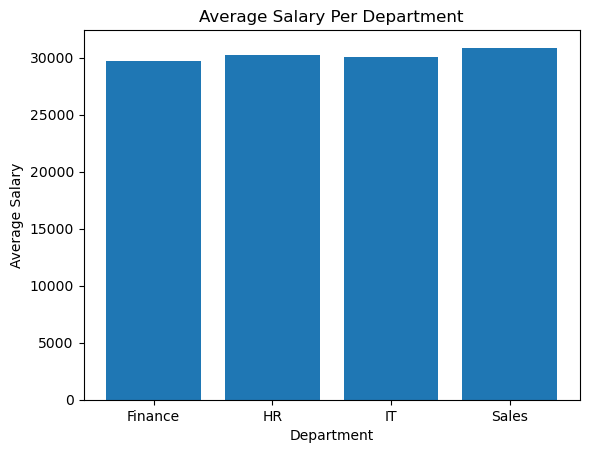

In [6]:
avg_salary = df.groupby("Department")["Salary"].mean()
plt.bar(avg_salary.index,avg_salary)
plt.title("Average Salary Per Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

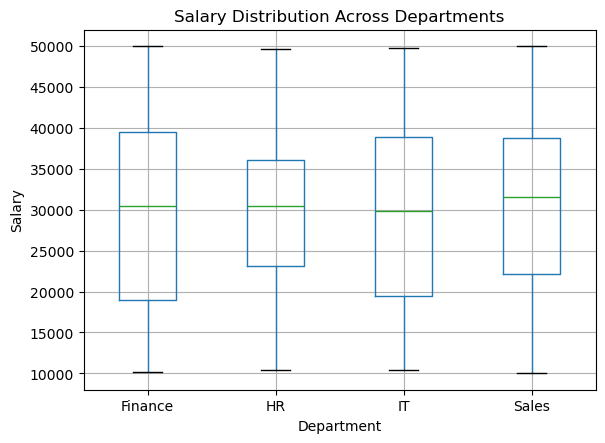

In [7]:
df.boxplot(column="Salary",by="Department")
plt.title("Salary Distribution Across Departments")
plt.suptitle("")   # removes automatic Pandas title
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()

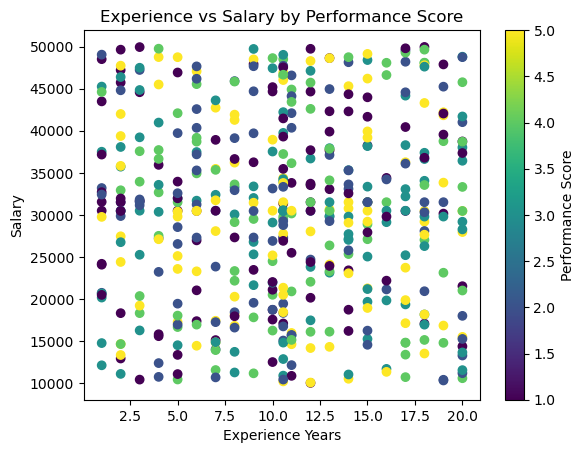

In [8]:
plt.scatter(
    df["Experience_Years"],
    df["Salary"],
    c=df["Performance_Score"]
)
plt.colorbar(label="Performance Score")
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience vs Salary by Performance Score")
plt.show()